# **Indian Road Accident Severity Prediction**

**End-to-end notebook:** data loading → data cleaning → crash-level reconstruction → feature engineering → EDA → model training → hyperparameter tuning → evaluation → risk-factor analysis → model export.

The target is `crash_severity`. The primary model intentionally excludes post-crash outcome/response variables to avoid target leakage and make the prediction useful at or near the time of the incident.


## 1. Project Objectives

The notebook will:

1. Load and inspect the updated ~135,000-row dataset.
2. Clean the raw occupant-level data.
3. Detect duplicate and inconsistent crash information.
4. Reconstruct one **crash-level dataset** from occupant-level records.
5. Exclude identifiers and post-outcome leakage variables.
6. Engineer temporal, safety, traffic, and occupant-aggregation features.
7. Perform comprehensive EDA.
8. Split data at the crash level using stratification.
9. Build preprocessing pipelines.
10. Train and tune:
   - Logistic Regression
   - Decision Tree
   - Random Forest
   - XGBoost
11. Compare models using macro-F1 and supporting metrics.
12. Evaluate the final model using accuracy, precision, recall, F1, ROC-AUC and confusion matrix.
13. Rank important risk factors.
14. Save the processed dataset, best model, metrics, and feature importance for Streamlit deployment.

### Prediction timing

The primary model predicts accident severity using information available from the crash context and occupant characteristics.

The following are therefore excluded from the prediction features:

- `injury_outcome`
- `hospitalized_flag`
- `estimated_recovery_days`
- `fatality_flag`
- `survived`
- `ambulance_called_flag`
- `emergency_response_time_min`

`computed_risk_score` is also excluded by default because its calculation/provenance is not supplied and it may already contain severity information.

`total_casualties_reported` is excluded from the primary model because it may only become known after the incident. It can be added later for a post-crash triage model.


## 2. Dataset Schema

Expected columns:

`record_id`, `occupant_unique_id`, `crash_ref_id`, `occupant_seq_no`, `city_name`, `state_name`, `lat_coord`, `lon_coord`, `incident_year`, `incident_month`, `incident_time`, `hour_of_day`, `weekday_name`, `weekend_flag`, `is_night_time`, `peak_hour_flag`, `festival_name`, `route_category`, `lane_count`, `signal_present_flag`, `weather_condition`, `visibility_level`, `temp_celsius`, `congestion_level`, `road_surface_condition`, `primary_cause`, `alcohol_suspected_flag`, `road_hazard_flag`, `crash_severity`, `vehicle_count`, `dominant_vehicle_type`, `occupants_per_vehicle`, `total_occupants_in_crash`, `speed_at_impact_kmph`, `computed_risk_score`, `passenger_age_years`, `passenger_gender`, `seat_position`, `helmet_or_seatbelt_used`, `airbag_deployed_flag`, `license_status`, `ambulance_called_flag`, `emergency_response_time_min`, `distance_to_hospital_km`, `total_casualties_reported`, `injury_outcome`, `hospitalized_flag`, `estimated_recovery_days`, `fatality_flag`, `survived`.

**Granularity:** occupant-level records nested within crashes.

**Target:** `crash_severity`.

**Source/provenance:** user-provided updated project dataset; no external provenance is assumed.


### **Installing Required Libraries**

In [2]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost joblib folium openpyxl


Note: you may need to restart the kernel to use updated packages.


### **Imports and configuration**

#### Importing Core Libraries

In [3]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

#### Importing Machine Learning Libraries

In [4]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

#### Folder and Path Configurations

In [5]:
RANDOM_STATE = 42

# Project directories
PROJECT_DIR = Path(".")
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
EDA_DIR = PROJECT_DIR / "eda_plots"
OUTPUT_DIR = PROJECT_DIR / "outputs"
METRICS_DIR = OUTPUT_DIR / "metrics"
MODEL_DIR = PROJECT_DIR / "models"

for folder in [RAW_DIR, PROCESSED_DIR, EDA_DIR, METRICS_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Change this filename if CSV has a different name.
DATA_PATH = RAW_DIR / "indian_road_accidents_passenger_level.csv"

print("Project directories ready.")
print("Expected data file:", DATA_PATH)

Project directories ready.
Expected data file: data\raw\indian_road_accidents_passenger_level.csv


#### Load data

In [6]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Place your CSV inside data/raw/ or update DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

print("Raw shape:", df.shape)
print("Raw memory usage:", round(df.memory_usage(deep=True).sum() / 1024**2, 2), "MB")
display(df.head())


Raw shape: (131404, 50)
Raw memory usage: 64.67 MB


,record_id,occupant_unique_id,crash_ref_id,occupant_seq_no,city_name,state_name,lat_coord,lon_coord,incident_year,incident_month,...,license_status,ambulance_called_flag,emergency_response_time_min,distance_to_hospital_km,total_casualties_reported,injury_outcome,hospitalized_flag,estimated_recovery_days,fatality_flag,survived
0,1,0_P1,0,1,Pune,Maharashtra,18.680827,73.930388,2023,10,...,expired,1,21.7,6.7,2,fatal,1,0,1,0
1,2,0_P2,0,2,Pune,Maharashtra,18.680827,73.930388,2023,10,...,valid,1,19.4,0.9,2,fatal,1,0,1,0
2,3,0_P3,0,3,Pune,Maharashtra,18.680827,73.930388,2023,10,...,expired,1,22.5,5.4,2,no_injury,0,0,0,1
3,4,0_P4,0,4,Pune,Maharashtra,18.680827,73.930388,2023,10,...,valid,1,20.0,3.7,2,no_injury,0,0,0,1
4,5,1_P1,1,1,Mumbai,Maharashtra,18.817732,72.790846,2023,5,...,valid,1,8.5,3.1,3,severe_injury,1,21,0,1


### **Initial structural inspection**

#### Inspecting Rows and Columns

In [7]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 131404
Columns: 50


#### Columns List

In [8]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['record_id', 'occupant_unique_id', 'crash_ref_id', 'occupant_seq_no', 'city_name', 'state_name', 'lat_coord', 'lon_coord', 'incident_year', 'incident_month', 'incident_time', 'hour_of_day', 'weekday_name', 'weekend_flag', 'is_night_time', 'peak_hour_flag', 'festival_name', 'route_category', 'lane_count', 'signal_present_flag', 'weather_condition', 'visibility_level', 'temp_celsius', 'congestion_level', 'road_surface_condition', 'primary_cause', 'alcohol_suspected_flag', 'road_hazard_flag', 'crash_severity', 'vehicle_count', 'dominant_vehicle_type', 'occupants_per_vehicle', 'total_occupants_in_crash', 'speed_at_impact_kmph', 'computed_risk_score', 'passenger_age_years', 'passenger_gender', 'seat_position', 'helmet_or_seatbelt_used', 'airbag_deployed_flag', 'license_status', 'ambulance_called_flag', 'emergency_response_time_min', 'distance_to_hospital_km', 'total_casualties_reported', 'injury_outcome', 'hospitalized_flag', 'estimated_recovery_days', 'fatality_flag', 'surv

#### Understanding Datatypes

In [9]:
print("\nData types:")
display(df.dtypes.to_frame("dtype"))


Data types:


,dtype
record_id,int64
occupant_unique_id,str
crash_ref_id,int64
occupant_seq_no,int64
city_name,str
state_name,str
lat_coord,float64
lon_coord,float64
incident_year,int64
incident_month,int64


#### Checking Missing Values

In [10]:
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))


Missing values:


,missing_count
festival_name,130694
record_id,0
occupant_unique_id,0
crash_ref_id,0
city_name,0
occupant_seq_no,0
lat_coord,0
lon_coord,0
incident_year,0
state_name,0


#### Duplicate, Unique Values & Target Distributions

In [11]:
print("\nExact duplicate rows:", df.duplicated().sum())

if "crash_ref_id" in df.columns:
    print("Unique crashes:", df["crash_ref_id"].nunique(dropna=True))

if "crash_severity" in df.columns:
    print("\nTarget distribution:")
    display(df["crash_severity"].value_counts(dropna=False).to_frame("count"))



Exact duplicate rows: 0
Unique crashes: 20000

Target distribution:


,count
crash_severity,
minor,72449
major,39317
fatal,19638


### **Data Cleaning**

Cleaning is performed **before crash-level reconstruction**, because duplicate rows, malformed values, blank strings, invalid ranges, and inconsistent identifiers should be handled at the raw-record level.

Learned imputation statistics are intentionally deferred to the scikit-learn preprocessing pipeline so they are learned only from the training data.


#### Standardize columns and blank values

In [ ]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r"[^a-z0-9]+", "_", regex=True)
      .str.strip("_")
)


Standardized columns: 50


#### Convert blank/whitespace-only strings to missing values

In [ ]:
object_cols = df.select_dtypes(include=["object", "string"]).columns

for col in object_cols:
    df[col] = df[col].astype("string").str.strip()
    df[col] = df[col].replace({
        "": pd.NA,
        "nan": pd.NA,
        "none": pd.NA,
        "null": pd.NA
    })

print("Standardized columns:", len(df.columns))

#### Normalize categorical values

In [ ]:
categorical_candidates = [
    "city_name", "state_name", "weekday_name", "festival_name",
    "route_category", "weather_condition", "visibility_level",
    "congestion_level", "road_surface_condition", "primary_cause",
    "dominant_vehicle_type", "passenger_gender", "seat_position",
    "helmet_or_seatbelt_used", "license_status", "injury_outcome",
    "crash_severity"
]

for col in categorical_candidates:
    if col in df.columns:
        df[col] = (
            df[col].astype("string")
                  .str.strip()
                  .str.lower()
                  .str.replace(r"\s+", "_", regex=True)
        )

#### Standardize common yes/no values to lowercase strings.

In [56]:
binary_candidates = [
    "weekend_flag", "is_night_time", "peak_hour_flag",
    "signal_present_flag", "alcohol_suspected_flag", "road_hazard_flag",
    "helmet_or_seatbelt_used", "airbag_deployed_flag",
    "ambulance_called_flag", "hospitalized_flag", "fatality_flag",
    "survived"
]

for col in binary_candidates:
    if col in df.columns and df[col].dtype == "object":
        df[col] = df[col].astype("string").str.lower().str.strip()

print("Categorical normalization complete.")

Categorical normalization complete.


#### Numeric coercion

In [ ]:
numeric_candidates = [
    "lat_coord", "lon_coord", "incident_year", "incident_month",
    "hour_of_day", "weekend_flag", "is_night_time", "peak_hour_flag",
    "lane_count", "signal_present_flag", "temp_celsius",
    "alcohol_suspected_flag", "road_hazard_flag", "vehicle_count",
    "occupants_per_vehicle", "total_occupants_in_crash",
    "speed_at_impact_kmph", "computed_risk_score",
    "passenger_age_years", "airbag_deployed_flag",
    "ambulance_called_flag", "emergency_response_time_min",
    "distance_to_hospital_km", "total_casualties_reported",
    "hospitalized_flag", "estimated_recovery_days",
    "fatality_flag", "survived"
]

for col in numeric_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Numeric conversion complete.")
display(df[numeric_candidates].dtypes.to_frame("dtype"))


Numeric conversion complete.


,dtype
lat_coord,float64
lon_coord,float64
incident_year,int64
incident_month,int64
hour_of_day,int64
weekend_flag,int64
is_night_time,int64
peak_hour_flag,int64
lane_count,int64
signal_present_flag,int64


#### Remove exact duplicates and records without essential keys

In [ ]:
before = len(df)

df = df.drop_duplicates().copy()

if "crash_ref_id" in df.columns:
    df = df[df["crash_ref_id"].notna()].copy()

if "crash_severity" in df.columns:
    df = df[df["crash_severity"].notna()].copy()

print("Rows before:", before)
print("Rows after :", len(df))
print("Rows removed:", before - len(df))


Rows before: 131404
Rows after : 131404
Rows removed: 0


#### Domain validation

In [ ]:
def report_invalid_range(data, col, low=None, high=None):
    if col not in data.columns:
        return
    s = data[col]
    mask = s.notna()
    if low is not None:
        mask &= s < low
    if high is not None:
        mask |= s > high
    print(f"{col}: {int(mask.sum())} potentially invalid values")

report_invalid_range(df, "lat_coord", 6, 37)
report_invalid_range(df, "lon_coord", 68, 98)
report_invalid_range(df, "incident_month", 1, 12)
report_invalid_range(df, "hour_of_day", 0, 23)
report_invalid_range(df, "lane_count", 1, None)
report_invalid_range(df, "passenger_age_years", 0, 120)
report_invalid_range(df, "speed_at_impact_kmph", 0, None)
report_invalid_range(df, "temp_celsius", -30, 60)
report_invalid_range(df, "vehicle_count", 1, None)
report_invalid_range(df, "total_occupants_in_crash", 1, None)


lat_coord: 0 potentially invalid values
lon_coord: 0 potentially invalid values
incident_month: 0 potentially invalid values
hour_of_day: 0 potentially invalid values
lane_count: 0 potentially invalid values
passenger_age_years: 0 potentially invalid values
speed_at_impact_kmph: 0 potentially invalid values
temp_celsius: 0 potentially invalid values
vehicle_count: 0 potentially invalid values
total_occupants_in_crash: 0 potentially invalid values


### Handling invalid physical values

Potentially invalid values are not automatically deleted because extreme accident conditions can be legitimate. The notebook reports suspicious values first.

For the model, numerical imputation occurs inside the training pipeline. If the dataset contains obvious data-entry errors, correct them only using a documented domain rule.

This is preferable to blindly deleting rare accidents.


### **Crash-Level Reconstruction**

This is the key change from the previous three-dataset workflow.

The raw data has multiple occupant rows per `crash_ref_id`. Directly training on these rows would give crashes with more occupants greater influence and can cause train/test leakage if rows from the same crash are split independently.

Therefore:

**occupant-level rows → group by `crash_ref_id` → one crash-level row**

Crash-level fields are retained once after consistency checking.

Occupant-level fields are converted to meaningful aggregate statistics such as:

- mean/min/max age
- age variation
- male/female ratio
- driver/rider/pillion/other ratios
- helmet/seatbelt usage rate
- airbag deployment rate
- invalid/expired license rate
- occupant count

Post-crash outcome fields are deliberately not aggregated into model features.


#### Check crash-level consistency

In [ ]:
crash_level_candidates = [
    "city_name", "state_name", "lat_coord", "lon_coord",
    "incident_year", "incident_month", "incident_time", "hour_of_day",
    "weekday_name", "weekend_flag", "is_night_time", "peak_hour_flag",
    "festival_name", "route_category", "lane_count",
    "signal_present_flag", "weather_condition", "visibility_level",
    "temp_celsius", "congestion_level", "road_surface_condition",
    "primary_cause", "alcohol_suspected_flag", "road_hazard_flag",
    "vehicle_count", "dominant_vehicle_type",
    "occupants_per_vehicle", "total_occupants_in_crash",
    "total_casualties_reported", "crash_severity"
]

consistency_rows = []

for col in crash_level_candidates:
    if col in df.columns:
        nunique = df.groupby("crash_ref_id")[col].nunique(dropna=True)
        inconsistent = int((nunique > 1).sum())
        consistency_rows.append({
            "column": col,
            "crashes_with_multiple_values": inconsistent
        })

consistency_df = pd.DataFrame(consistency_rows).sort_values(
    "crashes_with_multiple_values", ascending=False
)

display(consistency_df)


,column,crashes_with_multiple_values
20,road_surface_condition,7751
0,city_name,0
2,lat_coord,0
3,lon_coord,0
4,incident_year,0
1,state_name,0
6,incident_time,0
7,hour_of_day,0
8,weekday_name,0
9,weekend_flag,0


#### Remove crashes with conflicting target labels

In [ ]:
severity_counts = (
    df.groupby("crash_ref_id")["crash_severity"]
      .nunique(dropna=True)
)

conflicting_crashes = severity_counts[severity_counts > 1].index

print("Crashes with conflicting crash_severity labels:", len(conflicting_crashes))

if len(conflicting_crashes) > 0:
    df = df[~df["crash_ref_id"].isin(conflicting_crashes)].copy()

print("Remaining raw rows:", len(df))
print("Remaining unique crashes:", df["crash_ref_id"].nunique())


Crashes with conflicting crash_severity labels: 0
Remaining raw rows: 131404
Remaining unique crashes: 20000


#### Helper functions for occupant aggregation

In [ ]:
def normalized_string(s):
    return s.astype("string").str.strip().str.lower()

def yes_rate(s):
    x = normalized_string(s)
    return x.isin(["yes", "1", "true", "y"]).mean()

def value_rate(s, values):
    x = normalized_string(s)
    return x.isin(values).mean()

def category_ratio(s, keywords):
    x = normalized_string(s)
    return x.str.contains("|".join(map(str, keywords)), regex=True, na=False).mean()

def safe_std(s):
    return s.std(ddof=0)

def safe_mode(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    m = s.mode()
    return m.iloc[0] if len(m) else np.nan


#### Build one row per crash

In [ ]:
# Fields that represent the crash context and can safely be retained once
crash_first = [
    "city_name", "state_name", "lat_coord", "lon_coord",
    "incident_year", "incident_month", "incident_time", "hour_of_day",
    "weekday_name", "weekend_flag", "is_night_time", "peak_hour_flag",
    "festival_name", "route_category", "lane_count",
    "signal_present_flag", "weather_condition", "visibility_level",
    "temp_celsius", "congestion_level", "road_surface_condition",
    "primary_cause", "alcohol_suspected_flag", "road_hazard_flag",
    "vehicle_count", "dominant_vehicle_type",
    "occupants_per_vehicle", "total_occupants_in_crash",
    "crash_severity"
]

crash_first = [c for c in crash_first if c in df.columns]

agg_dict = {c: "first" for c in crash_first}

# Numeric occupant/crash characteristics
if "speed_at_impact_kmph" in df.columns:
    agg_dict["speed_at_impact_kmph"] = ["mean", "max", "min", "std"]

if "passenger_age_years" in df.columns:
    agg_dict["passenger_age_years"] = ["mean", "max", "min", "std"]

# Occupant safety and demographic summaries
if "helmet_or_seatbelt_used" in df.columns:
    agg_dict["helmet_or_seatbelt_used"] = yes_rate

if "airbag_deployed_flag" in df.columns:
    agg_dict["airbag_deployed_flag"] = "mean"

if "passenger_gender" in df.columns:
    agg_dict["passenger_gender"] = [
        lambda s: value_rate(s, ["male", "m"]),
        lambda s: value_rate(s, ["female", "f"])
    ]

if "seat_position" in df.columns:
    agg_dict["seat_position"] = [
        lambda s: category_ratio(s, ["driver"]),
        lambda s: category_ratio(s, ["rider"]),
        lambda s: category_ratio(s, ["pillion"]),
        lambda s: category_ratio(s, ["passenger", "co_passenger", "copassenger"])
    ]

if "license_status" in df.columns:
    agg_dict["license_status"] = [
        lambda s: value_rate(s, ["valid"]),
        lambda s: value_rate(s, ["expired", "invalid", "suspended"])
    ]

crash_df = df.groupby("crash_ref_id", sort=False).agg(agg_dict)

# Flatten MultiIndex columns
flat_columns = []
for col in crash_df.columns:
    if isinstance(col, tuple):
        base, func = col
        if callable(func):
            name = "custom"
        else:
            name = str(func)
        flat_columns.append(f"{base}_{name}")
    else:
        flat_columns.append(str(col))

crash_df.columns = flat_columns
crash_df = crash_df.reset_index()

# Rename generated columns to meaningful names
rename_map = {
    "speed_at_impact_kmph_mean": "mean_speed_at_impact_kmph",
    "speed_at_impact_kmph_max": "max_speed_at_impact_kmph",
    "speed_at_impact_kmph_min": "min_speed_at_impact_kmph",
    "speed_at_impact_kmph_std": "speed_at_impact_std",
    "passenger_age_years_mean": "mean_passenger_age",
    "passenger_age_years_max": "max_passenger_age",
    "passenger_age_years_min": "min_passenger_age",
    "passenger_age_years_std": "passenger_age_std",
}

crash_df = crash_df.rename(columns=rename_map)

# Because lambda names may be generic, identify them by source prefix and position.
gender_custom = [c for c in crash_df.columns if c.startswith("passenger_gender_")]
seat_custom = [c for c in crash_df.columns if c.startswith("seat_position_")]
license_custom = [c for c in crash_df.columns if c.startswith("license_status_")]

if len(gender_custom) >= 2:
    crash_df = crash_df.rename(columns={
        gender_custom[0]: "male_ratio",
        gender_custom[1]: "female_ratio"
    })

if len(seat_custom) >= 4:
    crash_df = crash_df.rename(columns={
        seat_custom[0]: "driver_ratio",
        seat_custom[1]: "rider_ratio",
        seat_custom[2]: "pillion_ratio",
        seat_custom[3]: "passenger_ratio"
    })

if len(license_custom) >= 2:
    crash_df = crash_df.rename(columns={
        license_custom[0]: "valid_license_ratio",
        license_custom[1]: "invalid_license_ratio"
    })

# Rename safety-rate function column
helmet_custom = [c for c in crash_df.columns if c.startswith("helmet_or_seatbelt_used_")]
if helmet_custom:
    crash_df = crash_df.rename(columns={helmet_custom[0]: "helmet_seatbelt_usage_rate"})

# Number of occupant records represented by each crash
occupant_counts = df.groupby("crash_ref_id").size().rename("occupant_record_count")
crash_df = crash_df.merge(occupant_counts, on="crash_ref_id", how="left")

print("Crash-level shape:", crash_df.shape)
display(crash_df.head())


Crash-level shape: (20000, 49)


,crash_ref_id,city_name_first,state_name_first,lat_coord_first,lon_coord_first,incident_year_first,incident_month_first,incident_time_first,hour_of_day_first,weekday_name_first,...,airbag_deployed_flag_mean,male_ratio,female_ratio,driver_ratio,rider_ratio,pillion_ratio,passenger_ratio,valid_license_ratio,invalid_license_ratio,occupant_record_count
0,0,pune,maharashtra,18.680827,73.930388,2023,10,5:00,5,sunday,...,0.0,0.5,0.5,0.0,0.75,0.25,0.0,0.5,0.5,4
1,1,mumbai,maharashtra,18.817732,72.790846,2023,5,4:00,4,sunday,...,0.0,0.75,0.25,0.625,0.0,0.0,0.375,0.75,0.25,8
2,2,mumbai,maharashtra,19.096889,72.819424,2024,7,13:00,13,wednesday,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1
3,3,chandigarh,punjab,30.787805,76.847507,2025,3,11:00,11,sunday,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.8,0.0,5
4,4,chennai,tamil_nadu,12.965155,80.283313,2024,1,16:00,16,thursday,...,0.0,1.0,0.0,0.0,0.5,0.5,0.0,1.0,0.0,2


#### Checking Records after Cleaning

In [ ]:
print("Raw occupant records:", len(df))
print("Unique crashes:", df["crash_ref_id"].nunique())
print("Crash-level records:", len(crash_df))

In [ ]:
print("\nCrash-level target distribution:")
display(crash_df["crash_severity_first"].value_counts(dropna=False).to_frame("count"))

In [ ]:
print("\nCrash-level missing values:")
display(
    crash_df.isna().sum()
             .sort_values(ascending=False)
             .to_frame("missing_count")
             .head(20)
)

Raw occupant records: 131404
Unique crashes: 20000
Crash-level records: 20000

Crash-level target distribution:


,count
crash_severity_first,
minor,11025
major,5988
fatal,2987



Crash-level missing values:


,missing_count
festival_name_first,19885
speed_at_impact_std,1554
passenger_age_std,1554
crash_ref_id,0
city_name_first,0
incident_year_first,0
incident_month_first,0
lat_coord_first,0
state_name_first,0
hour_of_day_first,0



Saved: data\processed\crash_level_accidents.csv


#### Saving the Cleaned Dataset

In [ ]:
crash_df.to_csv(PROCESSED_DIR / "crash_level_accidents.csv", index=False)
print("\nSaved:", PROCESSED_DIR / "crash_level_accidents.csv")

### **Feature Engineering**

The engineered features focus on:

- time cycles
- traffic/road conditions
- speed
- weather
- visibility
- occupant safety
- occupant demographics
- crash composition

IDs and target-leaking outcome variables remain excluded.


In [ ]:
def add_features(data):
    data = data.copy()

    # Cyclical time features
    if "hour_of_day" in data.columns:
        hour = pd.to_numeric(data["hour_of_day"], errors="coerce")
        data["hour_sin"] = np.sin(2 * np.pi * hour / 24)
        data["hour_cos"] = np.cos(2 * np.pi * hour / 24)

    if "incident_month" in data.columns:
        month = pd.to_numeric(data["incident_month"], errors="coerce")
        data["month_sin"] = np.sin(2 * np.pi * (month - 1) / 12)
        data["month_cos"] = np.cos(2 * np.pi * (month - 1) / 12)

    # Speed/road structure
    if {"mean_speed_at_impact_kmph", "lane_count"}.issubset(data.columns):
        lanes = data["lane_count"].replace(0, np.nan)
        data["speed_per_lane"] = data["mean_speed_at_impact_kmph"] / lanes

    if "mean_speed_at_impact_kmph" in data.columns:
        data["high_speed_flag"] = (
            data["mean_speed_at_impact_kmph"] >= 80
        ).astype(float)

    # Safety non-compliance
    if "helmet_seatbelt_usage_rate" in data.columns:
        data["safety_noncompliance_rate"] = (
            1 - data["helmet_seatbelt_usage_rate"]
        )

    # Interactions
    if {"is_night_time", "weekend_flag"}.issubset(data.columns):
        data["night_weekend_interaction"] = (
            pd.to_numeric(data["is_night_time"], errors="coerce") *
            pd.to_numeric(data["weekend_flag"], errors="coerce")
        )

    if {"road_hazard_flag", "is_night_time"}.issubset(data.columns):
        data["night_hazard_interaction"] = (
            pd.to_numeric(data["road_hazard_flag"], errors="coerce") *
            pd.to_numeric(data["is_night_time"], errors="coerce")
        )

    return data

crash_df = add_features(crash_df)

print("Feature engineering complete.")
display(crash_df.head())

Feature engineering complete.


,crash_ref_id,city_name_first,state_name_first,lat_coord_first,lon_coord_first,incident_year_first,incident_month_first,incident_time_first,hour_of_day_first,weekday_name_first,...,female_ratio,driver_ratio,rider_ratio,pillion_ratio,passenger_ratio,valid_license_ratio,invalid_license_ratio,occupant_record_count,high_speed_flag,safety_noncompliance_rate
0,0,pune,maharashtra,18.680827,73.930388,2023,10,5:00,5,sunday,...,0.5,0.0,0.75,0.25,0.0,0.5,0.5,4,1.0,0.5
1,1,mumbai,maharashtra,18.817732,72.790846,2023,5,4:00,4,sunday,...,0.25,0.625,0.0,0.0,0.375,0.75,0.25,8,0.0,0.5
2,2,mumbai,maharashtra,19.096889,72.819424,2024,7,13:00,13,wednesday,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1,0.0,1.0
3,3,chandigarh,punjab,30.787805,76.847507,2025,3,11:00,11,sunday,...,0.0,0.0,0.0,0.0,1.0,0.8,0.0,5,0.0,0.2
4,4,chennai,tamil_nadu,12.965155,80.283313,2024,1,16:00,16,thursday,...,0.0,0.0,0.5,0.5,0.0,1.0,0.0,2,0.0,0.5


### **Exploratory Data Analysis**

The following EDA is performed on the **crash-level dataset**, not the raw occupant-level dataset.

This avoids giving crashes with many occupants disproportionate weight.

For large visualizations, aggregation or sampling is used to keep memory and runtime reasonable on a 4 GB system.


#### EDA helper

In [ ]:
def save_fig(filename, dpi=150):
    path = EDA_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Saved:", path)


#### *Plot 1: Crash Severity Distributio*

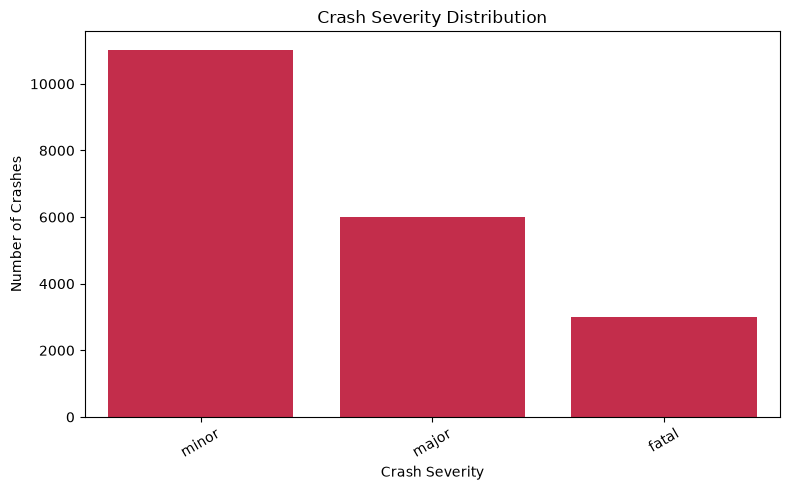

Saved: eda_plots\01_severity_distribution.png


In [57]:
plt.figure(figsize=(8, 5))
order = crash_df["crash_severity_first"].value_counts().index
sns.countplot(data=crash_df, x="crash_severity_first", order=order, color="crimson")
plt.title("Crash Severity Distribution")
plt.xlabel("Crash Severity")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=30)
save_fig("01_severity_distribution.png")

#### *Plot 2: Hourly Crash Severity Trend*

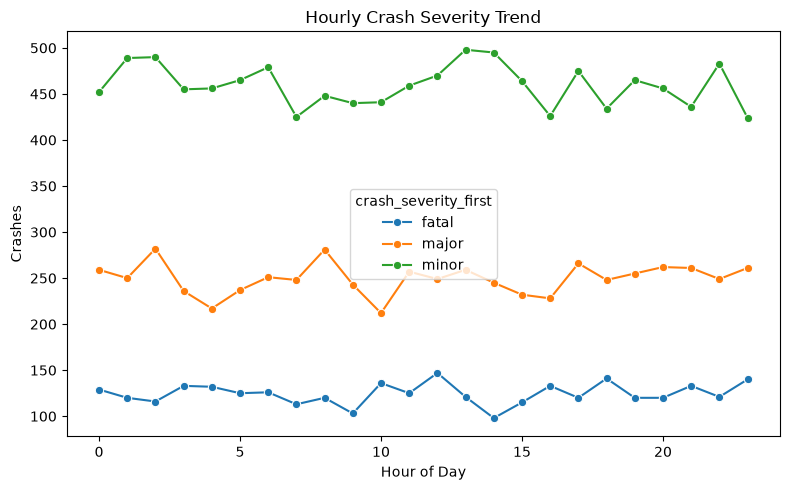

Saved: eda_plots\02_hourly_severity_trend.png


In [ ]:
hour_severity = (
    crash_df.groupby(["hour_of_day_first", "crash_severity_first"])
            .size()
            .reset_index(name="crashes")
)

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=hour_severity,
    x="hour_of_day_first",
    y="crashes",
    hue="crash_severity_first",
    marker="o"
)
plt.title("")
plt.xlabel("Hour of Day")
plt.ylabel("Crashes")
save_fig("02_hourly_severity_trend.png")

#### *Plot 3: Day-of-Week vs Crash Severity*

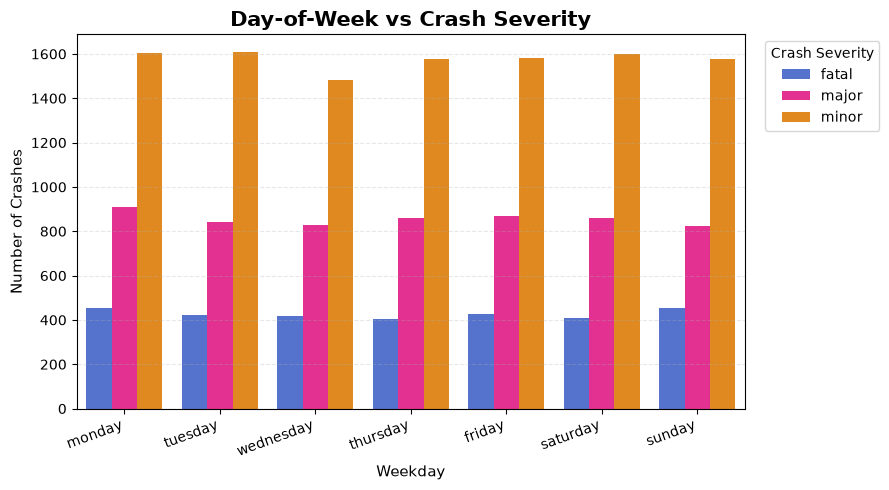

Saved: eda_plots\03_weekday_severity.png


In [ ]:
weekday_order = [
    "monday",
    "tuesday",
    "wednesday",
    "thursday",
    "friday",
    "saturday",
    "sunday"
]

plot_df = crash_df[
    ["weekday_name_first", "crash_severity_first"]
].dropna().copy()

plot_df["weekday_name_first"] = (
    plot_df["weekday_name_first"]
    .astype(str)
    .str.strip()
    .str.lower()
)

plot_df["crash_severity_first"] = (
    plot_df["crash_severity_first"]
    .astype(str)
    .str.strip()
    .str.lower()
)

plot_df = plot_df[
    plot_df["weekday_name_first"].isin(weekday_order)
]

tmp = (
    plot_df
    .groupby(
        ["weekday_name_first", "crash_severity_first"],
        observed=True
    )
    .size()
    .reset_index(name="crashes")
)

available_days = [
    day for day in weekday_order
    if day in plot_df["weekday_name_first"].unique()
]

severity_colors = {
    "minor": "darkorange",
    "moderate": "seagreen",
    "serious": "crimson",
    "severe": "darkviolet",
    "critical": "teal",
    "fatal": "royalblue",
    "major": "deeppink",
    "low": "goldenrod",
    "medium": "slateblue"
}

plt.figure(figsize=(9, 5))

sns.barplot(
    data=tmp,
    x="weekday_name_first",
    y="crashes",
    hue="crash_severity_first",
    order=available_days,
    palette=severity_colors,
    errorbar=None
)

plt.title(
    "",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Weekday", fontsize=11)
plt.ylabel("Number of Crashes", fontsize=11)

plt.xticks(rotation=20, ha="right")

plt.legend(
    title="Crash Severity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

save_fig("03_weekday_severity.png")

plt.show()

####  Day-of-week severity data

In [ ]:
display(
    tmp[
        [
            "weekday_name_first",
            "crash_severity_first",
            "crashes"
        ]
    ]
)

,weekday_name_first,crash_severity_first,crashes
0,friday,fatal,427
1,friday,major,869
2,friday,minor,1583
3,monday,fatal,456
4,monday,major,908
5,monday,minor,1602
6,saturday,fatal,410
7,saturday,major,858
8,saturday,minor,1599
9,sunday,fatal,453


#### *Plot 4: Monthly Crash Severity Trend*

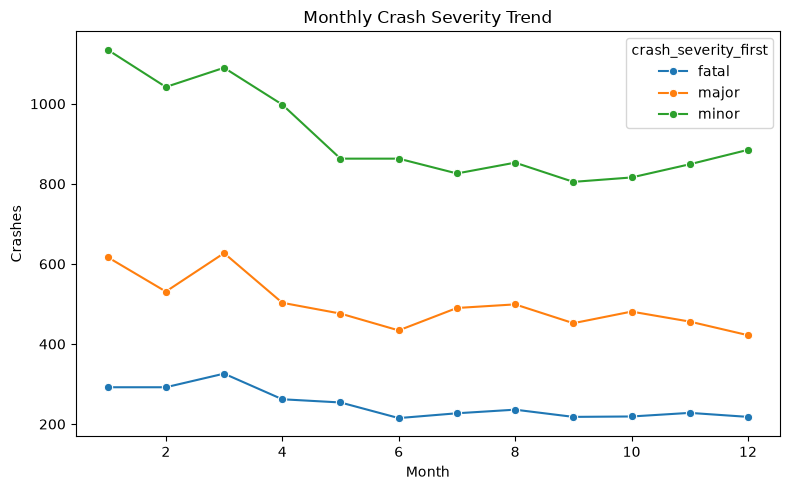

Saved: eda_plots\04_monthly_severity_trend.png


In [ ]:
monthly = (
    crash_df.groupby(["incident_month_first", "crash_severity_first"])
            .size()
            .reset_index(name="crashes")
)

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=monthly,
    x="incident_month_first",
    y="crashes",
    hue="crash_severity_first",
    marker="o"
)
plt.title("Monthly Crash Severity Trend")
plt.xlabel("Month")
plt.ylabel("Crashes")
save_fig("04_monthly_severity_trend.png")

#### *Plot 5: Yearly Crash Severity Trend*

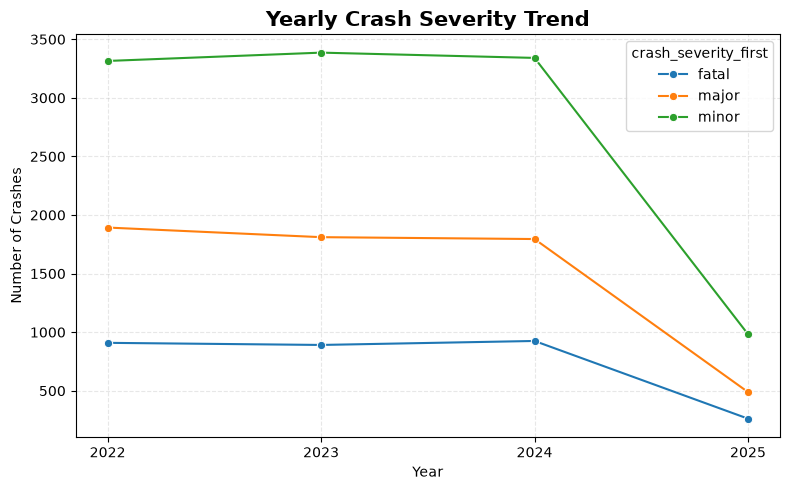

Saved: eda_plots\05_yearly_severity_trend.png


In [ ]:
yearly = (
    crash_df
    .dropna(subset=["incident_year_first", "crash_severity_first"])
    .groupby(["incident_year_first", "crash_severity_first"], observed=True)
    .size()
    .reset_index(name="crashes")
    .sort_values("incident_year_first")
)

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=yearly,
    x="incident_year_first",
    y="crashes",
    hue="crash_severity_first",
    marker="o"
)

plt.title(
    "Yearly Crash Severity Trend",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Number of Crashes")

plt.xticks(
    sorted(yearly["incident_year_first"].unique())
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.3
)

save_fig("05_yearly_severity_trend.png")

plt.show()

#### *Plot 6: Weather Condition vs Crash Severity*

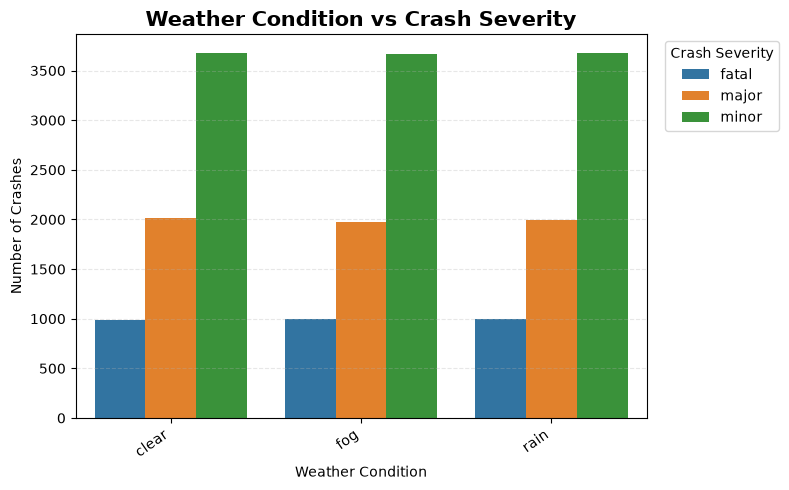

Saved: eda_plots\06_weather_severity.png


In [ ]:
weather = (
    crash_df
    .dropna(subset=["weather_condition_first", "crash_severity_first"])
    .groupby(
        ["weather_condition_first", "crash_severity_first"],
        observed=True
    )
    .size()
    .reset_index(name="crashes")
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=weather,
    x="weather_condition_first",
    y="crashes",
    hue="crash_severity_first",
    errorbar=None
)

plt.title(
    "Weather Condition vs Crash Severity",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Weather Condition")
plt.ylabel("Number of Crashes")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.legend(
    title="Crash Severity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

save_fig("06_weather_severity.png")

plt.show()

#### *Plot 7: Road Surface Condition vs Crash Severity*

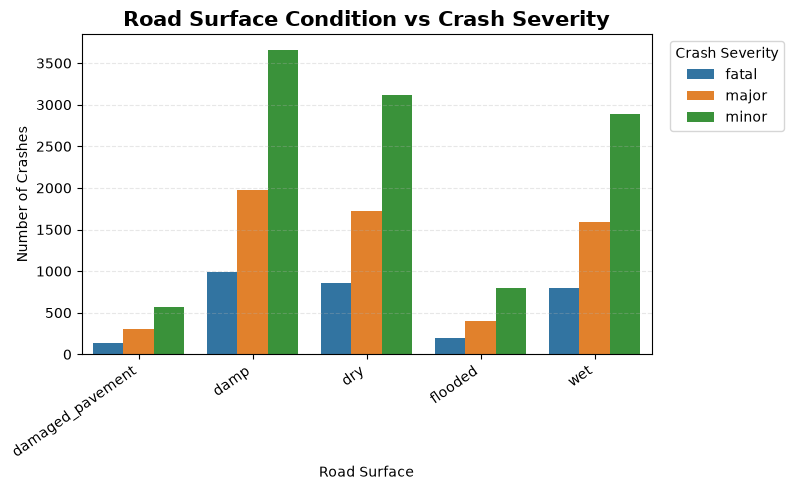

Saved: eda_plots\07_road_surface_severity.png


In [ ]:
surface = (
    crash_df
    .dropna(
        subset=[
            "road_surface_condition_first",
            "crash_severity_first"
        ]
    )
    .groupby(
        [
            "road_surface_condition_first",
            "crash_severity_first"
        ],
        observed=True
    )
    .size()
    .reset_index(name="crashes")
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=surface,
    x="road_surface_condition_first",
    y="crashes",
    hue="crash_severity_first",
    errorbar=None
)

plt.title(
    "Road Surface Condition vs Crash Severity",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Road Surface")
plt.ylabel("Number of Crashes")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.legend(
    title="Crash Severity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

save_fig("07_road_surface_severity.png")

plt.show()

#### *Plot 8: Dominant Vehicle Type vs Crash Severity*

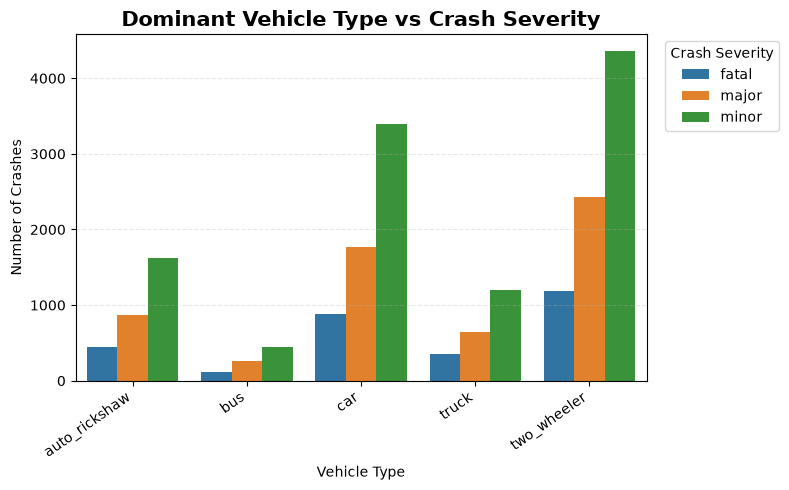

Saved: eda_plots\08_vehicle_type_severity.png


In [ ]:
vehicle = (
    crash_df
    .dropna(
        subset=[
            "dominant_vehicle_type_first",
            "crash_severity_first"
        ]
    )
    .groupby(
        [
            "dominant_vehicle_type_first",
            "crash_severity_first"
        ],
        observed=True
    )
    .size()
    .reset_index(name="crashes")
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=vehicle,
    x="dominant_vehicle_type_first",
    y="crashes",
    hue="crash_severity_first",
    errorbar=None
)

plt.title(
    "Dominant Vehicle Type vs Crash Severity",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Vehicle Type")
plt.ylabel("Number of Crashes")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.legend(
    title="Crash Severity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

save_fig("08_vehicle_type_severity.png")

plt.show()

#### *Plot 9: Primary Cause vs Crash Severity*

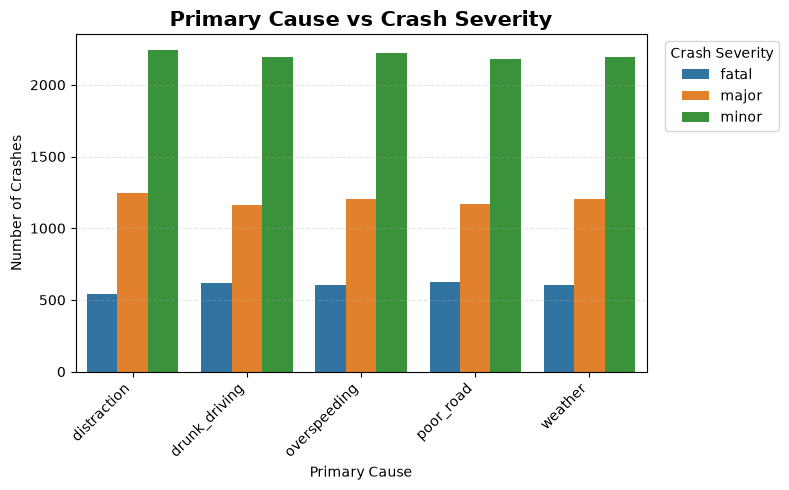

Saved: eda_plots\09_primary_cause_severity.png


In [ ]:
cause = (
    crash_df
    .dropna(
        subset=[
            "primary_cause_first",
            "crash_severity_first"
        ]
    )
    .groupby(
        [
            "primary_cause_first",
            "crash_severity_first"
        ],
        observed=True
    )
    .size()
    .reset_index(name="crashes")
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=cause,
    x="primary_cause_first",
    y="crashes",
    hue="crash_severity_first",
    errorbar=None
)

plt.title(
    "Primary Cause vs Crash Severity",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Primary Cause")
plt.ylabel("Number of Crashes")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Crash Severity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

save_fig("09_primary_cause_severity.png")

plt.show()

#### *Plot 10: Occupant/casualty distribution*

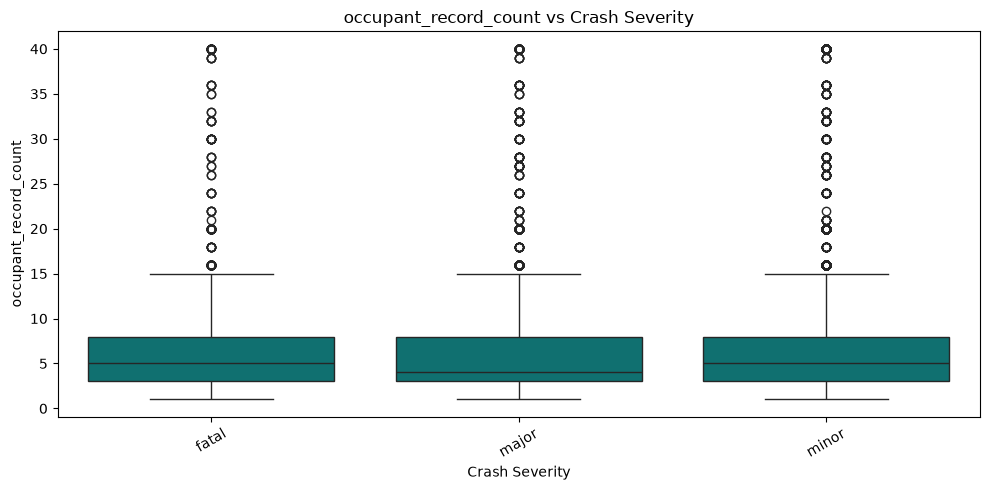

Saved: eda_plots\10_occupant_casualty_distribution.png


In [60]:
numeric_plot_col = (
    "total_casualties_reported"
    if "total_casualties_reported" in crash_df.columns
    else "occupant_record_count"
)

if numeric_plot_col in crash_df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=crash_df,
        x="crash_severity_first",
        y=numeric_plot_col,
        color="Teal"
    )
    plt.title(f"{numeric_plot_col} vs Crash Severity")
    plt.xlabel("Crash Severity")
    plt.ylabel(numeric_plot_col)
    plt.xticks(rotation=30)
    save_fig("10_occupant_casualty_distribution.png")

#### *Plot 11: Numerical Feature Correlation Heatmap*

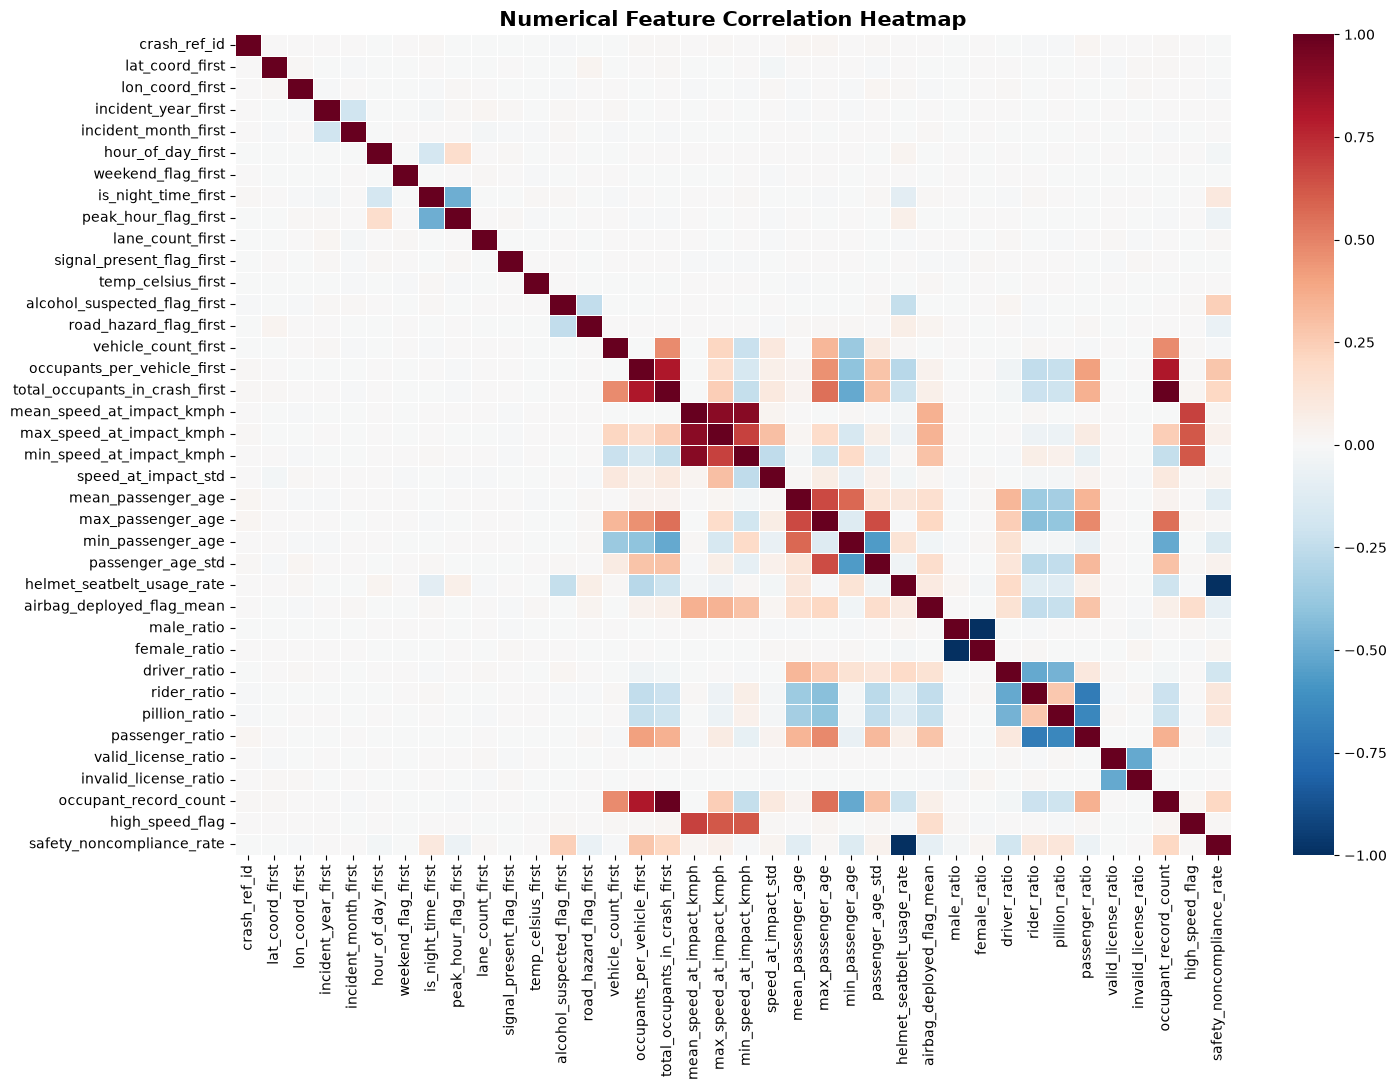

Saved: eda_plots\11_numeric_correlation_heatmap.png


In [61]:
numeric_cols = crash_df.select_dtypes(include=np.number).columns.tolist()

# Exclude IDs and target-coded fields from correlation visualization where appropriate
corr_df = crash_df[numeric_cols].copy()

if len(corr_df.columns) > 1:
    corr = corr_df.corr(numeric_only=True)

    plt.figure(figsize=(15, 11))

    sns.heatmap(
        corr,
        cmap="RdBu_r",
        center=0,
        square=False,
        annot=False,
        linewidths=0.5
    )

    plt.title(
        "Numerical Feature Correlation Heatmap",
        fontsize=15,
        fontweight="bold"
    )

    plt.tight_layout()

    save_fig("11_numeric_correlation_heatmap.png")

    plt.show()

#### *Plot 12: Mean Impact Speed vs Crash Severity*

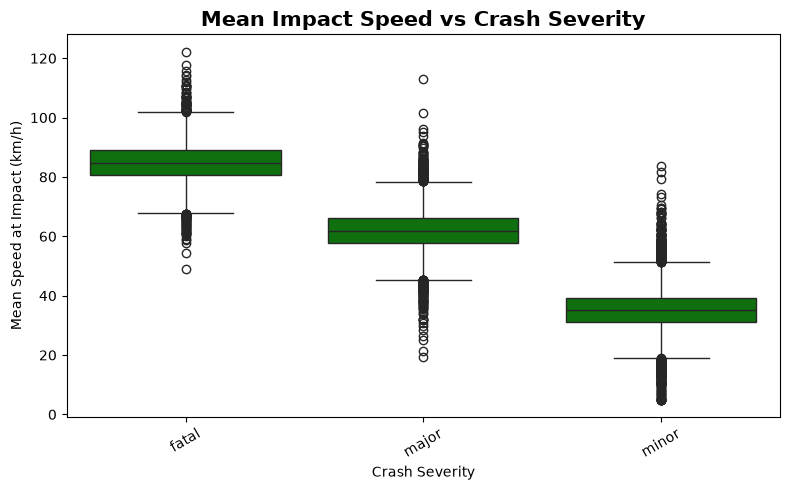

Saved: eda_plots\12_speed_vs_severity.png


In [63]:
if "mean_speed_at_impact_kmph" in crash_df.columns and "crash_severity_first" in crash_df.columns:

    plot_df = crash_df[
        ["crash_severity_first", "mean_speed_at_impact_kmph"]
    ].dropna().copy()

    plot_df["crash_severity_first"] = (
        plot_df["crash_severity_first"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=plot_df,
        x="crash_severity_first",
        y="mean_speed_at_impact_kmph",
        color="Green"
    )

    plt.title(
        "Mean Impact Speed vs Crash Severity",
        fontsize=15,
        fontweight="bold"
    )
    plt.xlabel("Crash Severity")
    plt.ylabel("Mean Speed at Impact (km/h)")
    plt.xticks(rotation=30)

    plt.tight_layout()

    save_fig("12_speed_vs_severity.png")

    plt.show()

#### *Plot 13: Mean Occupant Age vs Crash Severity*

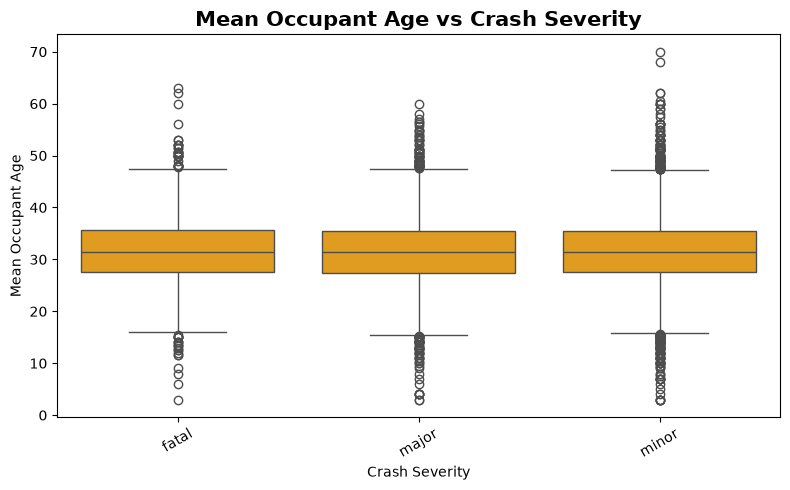

Saved: eda_plots\13_age_vs_severity.png


In [65]:
if "mean_passenger_age" in crash_df.columns and "crash_severity_first" in crash_df.columns:

    plot_df = crash_df[
        ["crash_severity_first", "mean_passenger_age"]
    ].dropna().copy()

    plot_df["crash_severity_first"] = (
        plot_df["crash_severity_first"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=plot_df,
        x="crash_severity_first",
        y="mean_passenger_age",
        color="Orange"
    )

    plt.title(
        "Mean Occupant Age vs Crash Severity",
        fontsize=15,
        fontweight="bold"
    )
    plt.xlabel("Crash Severity")
    plt.ylabel("Mean Occupant Age")
    plt.xticks(rotation=30)

    plt.tight_layout()

    save_fig("13_age_vs_severity.png")

    plt.show()

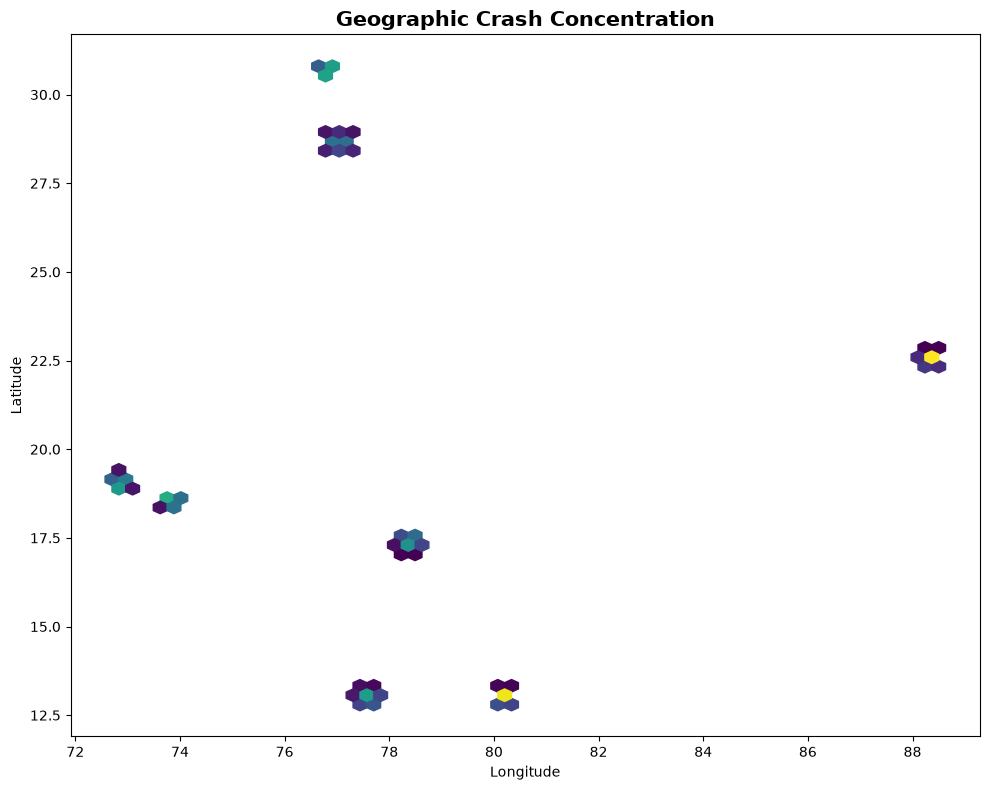

Saved: eda_plots\14_geographic_hotspots.png


In [38]:
# Cell 30 — 14. Geographic Hotspot Visualization

if {
    "lat_coord_first",
    "lon_coord_first",
    "crash_severity_first"
}.issubset(crash_df.columns):

    geo = crash_df[
        [
            "lat_coord_first",
            "lon_coord_first",
            "crash_severity_first"
        ]
    ].dropna().copy()

    # Sample large point sets to protect memory and plotting performance.
    if len(geo) > 20000:
        geo = geo.sample(20000, random_state=RANDOM_STATE)

    plt.figure(figsize=(10, 8))

    plt.hexbin(
        geo["lon_coord_first"],
        geo["lat_coord_first"],
        gridsize=60,
        mincnt=1
    )

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(
        "Geographic Crash Concentration",
        fontsize=15,
        fontweight="bold"
    )

    plt.tight_layout()

    save_fig("14_geographic_hotspots.png")

    plt.show()

### **Prepare Modeling Dataset**

#### Features excluded from modeling

- `record_id`
- `occupant_unique_id`
- `crash_ref_id`
- `occupant_seq_no`
- `computed_risk_score`
- `ambulance_called_flag`
- `emergency_response_time_min`
- `distance_to_hospital_km`
- `injury_outcome`
- `hospitalized_flag`
- `estimated_recovery_days`
- `fatality_flag`
- `survived`
- `total_casualties_reported` for the primary pre-/at-crash model

These variables are either identifiers, grouping keys, uncertain derived scores, or post-crash outcomes.

The target `crash_severity` is never included in X.


#### Define target and leakage-safe feature set

In [ ]:
TARGET = "crash_severity_first"

DROP_FEATURES = [
    "record_id",
    "occupant_unique_id",
    "crash_ref_id",
    "occupant_seq_no",
    "computed_risk_score",
    "ambulance_called_flag",
    "emergency_response_time_min",
    "distance_to_hospital_km",
    "injury_outcome",
    "hospitalized_flag",
    "estimated_recovery_days",
    "fatality_flag",
    "survived",
    "total_casualties_reported",
    TARGET
]

# Drop only columns that actually exist in crash_df
DROP_FEATURES = [
    c for c in DROP_FEATURES
    if c in crash_df.columns
]

X = crash_df.drop(columns=DROP_FEATURES).copy()

y_raw = (
    crash_df[TARGET]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Remove accidental string representations of missing target values
valid_target = ~y_raw.isin(["nan", "none", ""])

X = X.loc[valid_target].copy()
y_raw = y_raw.loc[valid_target].copy()

print("Modeling X shape:", X.shape)
print("Target classes:", sorted(y_raw.unique()))

display(
    y_raw.value_counts()
    .to_frame("count")
)

Modeling X shape: (20000, 49)
Target classes: ['fatal', 'major', 'minor']


,count
crash_severity_first,
minor,11025
major,5988
fatal,2987


#### Encode target

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print("Encoded classes:")
for idx, label in enumerate(label_encoder.classes_):
    print(idx, "->", label)


Encoded classes:
0 -> fatal
1 -> major
2 -> minor


#### Train/test split

In [ ]:
# Stratification preserves the severity distribution.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (16000, 49)
Test : (4000, 49)

Training target distribution:


,count
0,2390
1,4790
2,8820



Testing target distribution:


,count
0,597
1,1198
2,2205


#### Training target distribution

In [ ]:
print("\nTraining target distribution:")
display(pd.Series(y_train).value_counts().sort_index().to_frame("count"))

#### Testing target distribution

In [ ]:
print("\nTesting target distribution:")
display(pd.Series(y_test).value_counts().sort_index().to_frame("count"))

#### Identify numeric and categorical columns

In [ ]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)


Numeric features: 37
['lat_coord_first', 'lon_coord_first', 'incident_year_first', 'incident_month_first', 'hour_of_day_first', 'weekend_flag_first', 'is_night_time_first', 'peak_hour_flag_first', 'lane_count_first', 'signal_present_flag_first', 'temp_celsius_first', 'alcohol_suspected_flag_first', 'road_hazard_flag_first', 'vehicle_count_first', 'occupants_per_vehicle_first', 'total_occupants_in_crash_first', 'mean_speed_at_impact_kmph', 'max_speed_at_impact_kmph', 'min_speed_at_impact_kmph', 'speed_at_impact_std', 'mean_passenger_age', 'max_passenger_age', 'min_passenger_age', 'passenger_age_std', 'helmet_seatbelt_usage_rate', 'airbag_deployed_flag_mean', 'male_ratio', 'female_ratio', 'driver_ratio', 'rider_ratio', 'pillion_ratio', 'passenger_ratio', 'valid_license_ratio', 'invalid_license_ratio', 'occupant_record_count', 'high_speed_flag', 'safety_noncompliance_rate']

Categorical features: 12
['city_name_first', 'state_name_first', 'incident_time_first', 'weekday_name_first', 'fest

### **Preprocessing**

Numerical features:

- median imputation
- standardization

Categorical features:

- most-frequent imputation
- one-hot encoding
- unknown categories ignored

The preprocessing is placed inside each model's Pipeline. This prevents information from the test set leaking into training-time transformations.


#### Preprocessing pipeline factory

In [ ]:
def make_preprocessor(scale_numeric=True):
    if scale_numeric:
        numeric_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
    else:
        numeric_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        ))
    ])

    return ColumnTransformer([
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features)
    ])


### **Model Selection Strategy**

Models:

1. **Logistic Regression** — interpretable baseline.
2. **Decision Tree** — easy nonlinear rules and interpretability.
3. **Random Forest** — robust tree ensemble.
4. **XGBoost** — strong gradient-boosting candidate.

### Primary selection metric

**Macro-F1** is the primary metric because accident severity is likely to be imbalanced and rare severe/fatal cases should not be hidden by high overall accuracy.

Supporting metrics:

- Accuracy
- Macro Precision
- Macro Recall
- Weighted F1
- Multiclass ROC-AUC where applicable
- Confusion matrix
- Fatal/severe class recall when those classes exist

Because the current system may run on a 4 GB machine, randomized searches are deliberately small and `n_jobs=1` is used to control memory consumption.


#### Cross-validation

In [ ]:
min_class_count = pd.Series(y_train).value_counts().min()

if min_class_count >= 5:
    n_splits = 5
elif min_class_count >= 3:
    n_splits = 3
else:
    n_splits = 2

cv = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("CV folds:", n_splits)


CV folds: 5


#### Model definitions and parameter spaces

In [ ]:
n_classes = len(label_encoder.classes_)

models_and_params = {}

# 1. Logistic Regression
logistic_pipe = Pipeline([
    ("preprocessor", make_preprocessor(scale_numeric=True)),
    ("model", LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

models_and_params["Logistic Regression"] = (
    logistic_pipe,
    {
        "model__C": [0.01, 0.1, 1.0, 5.0, 10.0]
    }
)

# 2. Decision Tree
tree_pipe = Pipeline([
    ("preprocessor", make_preprocessor(scale_numeric=False)),
    ("model", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

models_and_params["Decision Tree"] = (
    tree_pipe,
    {
        "model__max_depth": [3, 5, 8, 12, 16],
        "model__min_samples_split": [5, 10, 20],
        "model__min_samples_leaf": [2, 5, 10]
    }
)

# 3. Random Forest (trimmed n_estimators to protect memory and runtime)
rf_pipe = Pipeline([
    ("preprocessor", make_preprocessor(scale_numeric=False)),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])

models_and_params["Random Forest"] = (
    rf_pipe,
    {
        "model__n_estimators": [100, 150],
        "model__max_depth": [8, 15, 20],
        "model__min_samples_split": [5, 10],
        "model__min_samples_leaf": [2, 5],
        "model__max_features": ["sqrt", "log2"]
    }
)

# 4. XGBoost
if n_classes == 2:
    xgb_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=1
    )
else:
    xgb_model = XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=1
    )

xgb_pipe = Pipeline([
    ("preprocessor", make_preprocessor(scale_numeric=False)),
    ("model", xgb_model)
])

models_and_params["XGBoost"] = (
    xgb_pipe,
    {
        "model__n_estimators": [100, 150],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.03, 0.08, 0.15],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0],
        "model__min_child_weight": [1, 5]
    }
)

print("Models prepared:", list(models_and_params.keys()))

Models prepared: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']


#### Insert directly to wipe any pd.NA objects

In [ ]:
import numpy as np

for col in categorical_features:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype(object).replace({pd.NA: np.nan})
    if col in X_test.columns:
        X_test[col] = X_test[col].astype(object).replace({pd.NA: np.nan})

for col in numeric_features:
    if col in X_train.columns:
        X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
    if col in X_test.columns:
        X_test[col] = pd.to_numeric(X_test[col], errors="coerce")

#### Tune all models

In [ ]:
import time
import gc
from sklearn.model_selection import ParameterGrid

search_results = {}
best_estimators = {}

for model_name, (pipeline, param_grid) in models_and_params.items():
    print("\n" + "=" * 70)
    print(f"Tuning: {model_name}")
    print("=" * 70)

    # Prevent warning when candidate combinations are fewer than 10
    total_combos = len(ParameterGrid(param_grid))
    effective_n_iter = min(10, total_combos)
    print(f"Testing {effective_n_iter} out of {total_combos} possible parameter settings...")

    start_time = time.time()

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grid,
        n_iter=effective_n_iter,
        scoring="f1_macro",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=1,
        refit=True,
        error_score=np.nan
    )

    search.fit(X_train, y_train)

    elapsed_min = (time.time() - start_time) / 60.0

    search_results[model_name] = search
    best_estimators[model_name] = search.best_estimator_

    print(f"Completed in: {elapsed_min:.2f} minutes")
    print("Best CV macro-F1:", round(search.best_score_, 4))
    print("Best parameters:", search.best_params_)

    # Free memory between large model iterations
    gc.collect()


Tuning: Logistic Regression
Testing 5 out of 5 possible parameter settings...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Completed in: 1.02 minutes
Best CV macro-F1: 0.9298
Best parameters: {'model__C': 10.0}

Tuning: Decision Tree
Testing 10 out of 45 possible parameter settings...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Completed in: 0.68 minutes
Best CV macro-F1: 0.9288
Best parameters: {'model__min_samples_split': 10, 'model__min_samples_leaf': 5, 'model__max_depth': 3}

Tuning: Random Forest
Testing 10 out of 48 possible parameter settings...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Completed in: 4.22 minutes
Best CV macro-F1: 0.9308
Best parameters: {'model__n_estimators': 150, 'model__min_samples_split': 5, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 20}

Tuning: XGBoost
Testing 10 out of 144 possible parameter settings...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
C

#### Compare tuned models on the held-out test set

In [ ]:
def calculate_metrics(model, X_eval, y_eval):
    pred = model.predict(X_eval)

    metrics = {
        "accuracy": accuracy_score(y_eval, pred),
        "precision_macro": precision_score(
            y_eval, pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_eval, pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_eval, pred, average="macro", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_eval, pred, average="weighted", zero_division=0
        )
    }

    if hasattr(model, "predict_proba"):
        try:
            proba = model.predict_proba(X_eval)
            metrics["roc_auc_ovr_weighted"] = roc_auc_score(
                y_eval,
                proba,
                multi_class="ovr",
                average="weighted"
            )
        except ValueError:
            metrics["roc_auc_ovr_weighted"] = np.nan

    return metrics

comparison = []

for name, model in best_estimators.items():
    metrics = calculate_metrics(model, X_test, y_test)
    metrics["model"] = name
    comparison.append(metrics)

comparison_df = pd.DataFrame(comparison).set_index("model")
comparison_df = comparison_df.sort_values("f1_macro", ascending=False)

display(comparison_df.round(4))

comparison_df.to_csv(METRICS_DIR / "model_comparison.csv")
print("Saved:", METRICS_DIR / "model_comparison.csv")


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc_ovr_weighted
model,,,,,,
XGBoost,0.9512,0.9406,0.9397,0.9401,0.9513,0.9944
Random Forest,0.9442,0.9278,0.9391,0.9332,0.9446,0.9925
Logistic Regression,0.9448,0.9261,0.9406,0.9330,0.9451,0.9898
Decision Tree,0.9415,0.9211,0.9400,0.9299,0.9419,0.9833


Saved: outputs\metrics\model_comparison.csv


In [49]:
# Cell 40 — Select final model by macro-F1

best_model_name = comparison_df.index[0]
best_model = best_estimators[best_model_name]

print("Selected model:", best_model_name)
print("Test macro-F1:", round(comparison_df.loc[best_model_name, "f1_macro"], 4))


Selected model: XGBoost
Test macro-F1: 0.9401


####  Detailed final evaluation

Classification Report
              precision    recall  f1-score   support

       fatal       0.93      0.92      0.93       597
       major       0.91      0.93      0.92      1198
       minor       0.98      0.97      0.98      2205

    accuracy                           0.95      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.95      0.95      0.95      4000



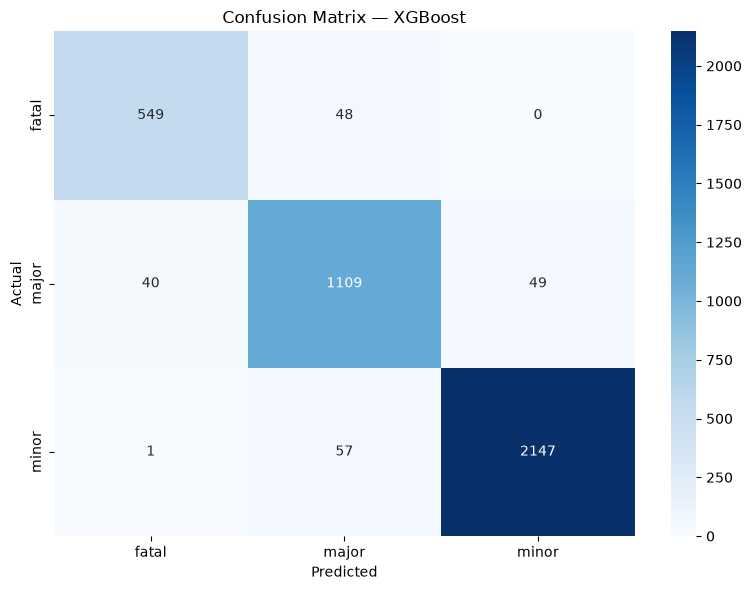

Saved: outputs\confusion_matrix_best_model.png


In [ ]:
y_pred = best_model.predict(X_test)

print("Classification Report")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

cm_path = OUTPUT_DIR / "confusion_matrix_best_model.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", cm_path)


### **Preliminary Risk-Factor Ranking**

The ranking below is based on the final fitted model's global feature importance.

For linear models, the mean absolute coefficient magnitude is used.

For tree models, `feature_importances_` is used.

One-hot encoded features are kept individually so categories such as weather or road type can be identified. For a production dashboard, these can also be aggregated back to their original feature groups.


#### Extract transformed feature importance

,feature,importance
35,num__high_speed_flag,0.558421
16,num__mean_speed_at_impact_kmph,0.137277
17,num__max_speed_at_impact_kmph,0.034642
18,num__min_speed_at_impact_kmph,0.021044
25,num__airbag_deployed_flag_mean,0.014003
111,cat__dominant_vehicle_type_first_car,0.009805
34,num__occupant_record_count,0.008961
15,num__total_occupants_in_crash_first,0.007772
19,num__speed_at_impact_std,0.003738
13,num__vehicle_count_first,0.003552


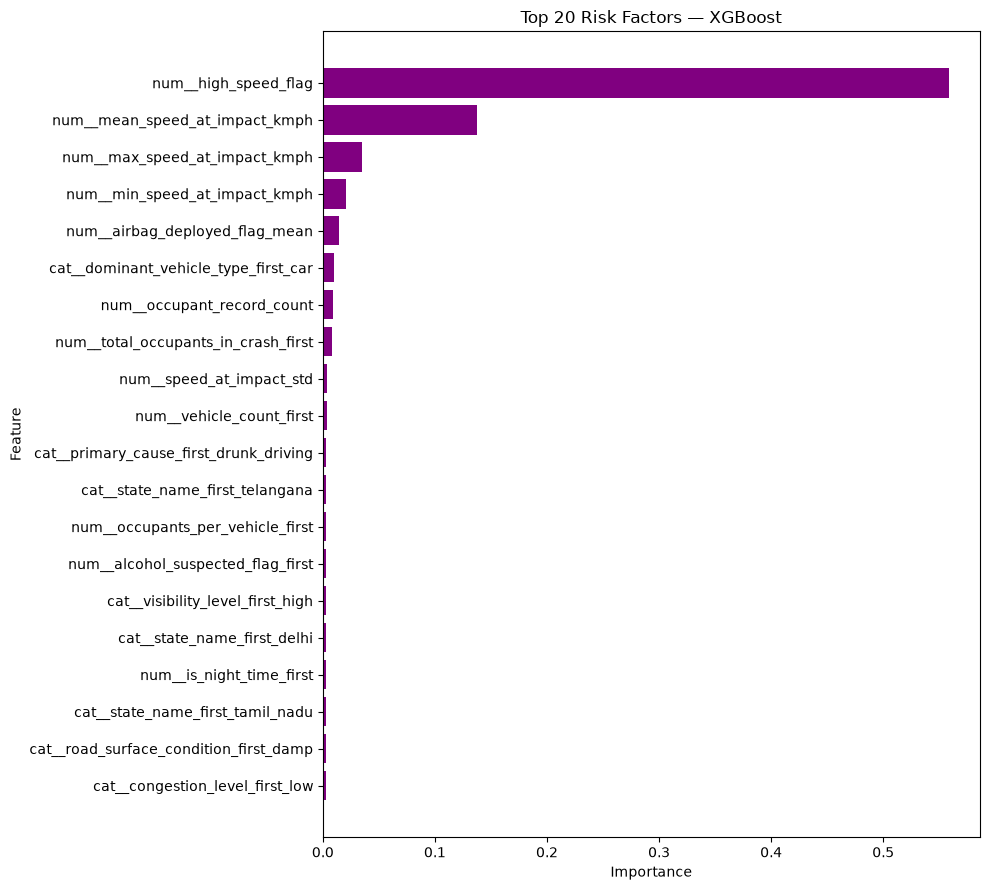

Saved: eda_plots\15_top_risk_factors.png


In [68]:
preprocessor = best_model.named_steps["preprocessor"]
estimator = best_model.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()

if hasattr(estimator, "feature_importances_"):
    importance_values = estimator.feature_importances_
elif hasattr(estimator, "coef_"):
    coef = estimator.coef_
    importance_values = np.mean(np.abs(coef), axis=0)
else:
    importance_values = None

if importance_values is not None:
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importance_values
    }).sort_values("importance", ascending=False)

    display(importance_df.head(30))

    importance_df.to_csv(
        OUTPUT_DIR / "risk_factor_importance.csv",
        index=False
    )

    plt.figure(figsize=(10, 9))
    top = importance_df.head(20).sort_values("importance")
    plt.barh(top["feature"], top["importance"], color="Purple")
    plt.title(f"Top 20 Risk Factors — {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    save_fig("15_top_risk_factors.png")
else:
    importance_df = pd.DataFrame()
    print("Feature importance is not directly available for this estimator.")


### **Geographic High-Risk Locations**

A hotspot should not be declared high-risk solely because it has one severe crash.

The recommended approach is to:

1. Group crashes by city or geographic grid.
2. Calculate crash count.
3. Calculate severe-crash rate.
4. Apply a minimum crash-count threshold.
5. Rank locations by severe-crash rate with sufficient sample size.

This avoids unstable rankings caused by tiny samples.


#### City-Level Risk Summary

In [ ]:
if {"city_name", "crash_severity"}.issubset(crash_df.columns):
    city_summary = (
        crash_df.groupby("city_name")
                .agg(
                    crashes=("crash_severity", "size"),
                    severe_rate=("crash_severity", lambda s: (
                        s.astype(str).str.lower()
                         .str.contains("fatal|severe|major", regex=True)
                         .mean()
                    ))
                )
                .reset_index()
    )

    # Minimum sample size avoids ranking tiny locations as hotspots.
    city_summary = city_summary[city_summary["crashes"] >= 30].copy()
    city_summary = city_summary.sort_values(
        ["severe_rate", "crashes"],
        ascending=[False, False]
    )

    display(city_summary.head(20))

    city_summary.to_csv(
        OUTPUT_DIR / "high_risk_cities.csv",
        index=False
    )


### **Save the Complete Model Bundle**

The preprocessing and model are saved together.

This is important for Streamlit: the application must perform exactly the same preprocessing as training.

The saved bundle contains:

- fitted Pipeline
- LabelEncoder
- original model feature columns
- selected model name
- class labels


####  Save model bundle

In [ ]:
model_bundle = {
    "pipeline": best_model,
    "label_encoder": label_encoder,
    "feature_columns": X.columns.tolist(),
    "target": TARGET,
    "model_name": best_model_name,
    "classes": label_encoder.classes_.tolist()
}

MODEL_PATH = MODEL_DIR / "best_model_bundle.joblib"

joblib.dump(model_bundle, MODEL_PATH)

print("Saved model bundle:", MODEL_PATH)


Saved model bundle: models\best_model_bundle.joblib


In [71]:
# Cell 46 — Final output summary

print("-" * 70)
print("PROJECT COMPLETE")
print("-" * 70)

print("Raw occupant records:", len(df))
print("Unique crashes:", df["crash_ref_id"].nunique())
print("Crash-level modeling records:", len(crash_df))
print("Target classes:", list(label_encoder.classes_))
print("Best model:", best_model_name)
print("Test macro-F1:", round(comparison_df.loc[best_model_name, "f1_macro"], 4))

print("\nGenerated directories:")
print("EDA plots       :", EDA_DIR)
print("Processed data  :", PROCESSED_DIR)
print("Metrics          :", METRICS_DIR)
print("Model            :", MODEL_DIR)
print("Outputs          :", OUTPUT_DIR)


----------------------------------------------------------------------
PROJECT COMPLETE
----------------------------------------------------------------------
Raw occupant records: 131404
Unique crashes: 20000
Crash-level modeling records: 20000
Target classes: ['fatal', 'major', 'minor']
Best model: XGBoost
Test macro-F1: 0.9401

Generated directories:
EDA plots       : eda_plots
Processed data  : data\processed
Metrics          : outputs\metrics
Model            : models
Outputs          : outputs
